# Coloration black-box LSTM — Local Eval

Evaluates models trained by [`train_lstm_color_blackbox.ipynb`](train_lstm_color_blackbox.ipynb)
(`ColorBlackboxLSTM`): the unchanged diffssl `LSTM32TVC` SOTA trunk (`tvcond` on
`|matched|` + 4 static knobs) fed the **amplitude-matched** signal instead of the
raw dry. Gain is an explicit multiply (obeys any GR source by construction); the
trunk only has to learn the easier matched → wet **coloration**:

```
matched = x · 10^(gr/20)                    ← gain: explicit multiply, obeys
y = tanh( lin( LSTM(matched ⊕ tvcond) ) )   ← coloration: SOTA LSTM32TVC trunk
```

- **Input**: the amplitude-matched signal `x·10^(gr/20)` + the 4 static knobs
  (`tvcond`, from the setting name). **The model never sees the GR value itself** —
  the gain is already baked into its input, so there is nothing to disobey and any
  commanded GR trajectory (incl. a sidechain-predicted one) is applied exactly.
- **No Δg, no waveshaper, no additive head, no zero-init anchor.** The only model
  decomposition is `color = y − matched`, the total learned coloration (the
  `return_parts_full` Δg / waveshaper slots are `≡ 0` for this model).
- **Target**: wet audio.  **Stateful inference**: whole-song streaming with
  `reset_states()`.

The metric engine, streaming and ablation cells are **byte-identical** to
[`eval_lstm_gain_prior_ws.ipynb`](eval_lstm_gain_prior_ws.ipynb), so the 9-column
numbers drop straight into the cross-model comparison. Only the model class, the
coloration decomposition and the swapped **coloration-spectra** plot (replacing the
waveshaper transfer curve — this model has no static transfer curve) differ.


In [1]:
# ── 0. Imports and defaults ─────────────────────────────────────────

import gc, glob, json, os, sys, types, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore", category=UserWarning)

# model_color_lstm imports nablafx's TVFiLMCond. Stub the `rational` /
# `frechet_audio_distance` import-chain deps so `from nablafx...` doesn't drag in
# broken wheels — identical to the train notebook's cell 0.
_rational = types.ModuleType("rational")
_rational.torch = types.ModuleType("rational.torch")
_rational.torch.Rational = type("Rational", (), {})
sys.modules.setdefault("rational", _rational)
sys.modules.setdefault("rational.torch", _rational.torch)
_fad = types.ModuleType("frechet_audio_distance")
_fad.FrechetAudioDistance = type("FrechetAudioDistance", (), {})
sys.modules.setdefault("frechet_audio_distance", _fad)

REPO_ROOT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "pyproject.toml").is_file()),
    Path.cwd().resolve(),
)
sys.path.insert(0, str(REPO_ROOT))                       # `src`
sys.path.insert(0, str(REPO_ROOT / "nablafx"))           # raw ./nablafx/ clone (TVFiLMCond)
sys.path.insert(0, str(REPO_ROOT / "06_output"))
sys.path.insert(0, str(REPO_ROOT / "03_initial_GR_pred"))  # eval_helpers, gr_dataset

from amplitude_match import GR_DB_MIN, GR_DB_MAX, amplitude_match
from model_color_lstm import ColorBlackboxLSTM
from splits import SplitManifest, normalize_setting_params
from system_gainprior import esr_metric
from eval_helpers import (
    _checkpoint_sort_key, _find_hparams_json, _pair_num_frames,
    _read_dry_wet_segment, _weighted_average_metric_rows, latest_best_checkpoint,
    list_runs, plot_loss_curves, wet_dir_for_setting,
)
from src.dsp_torch import RMS_WINDOW, gain_reduction_db

DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp"
RUNS_DIR = "/Volumes/Saola's Drive/AllCode/thesis/data/diffssl_gain_prior_runs"
DEVICE = "cpu"

print(f"torch {torch.__version__}  |  device: {DEVICE}")
print(f"GR clamp: [{GR_DB_MIN}, {GR_DB_MAX}] dB  |  RMS window: {RMS_WINDOW} samples")


/Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.10.0  |  device: cpu
GR clamp: [-30.0, 5.0] dB  |  RMS window: 1024 samples


In [2]:
# ── 1. List available coloration black-box runs ──────────────────────

MODEL_TYPE = "ColorBlackboxLSTM"   # hparams["model_type"]

runs_df = list_runs(RUNS_DIR)
assert not runs_df.empty, f"No runs in {RUNS_DIR}"
available_models_df = runs_df[runs_df["type"] == MODEL_TYPE].copy()
if available_models_df.empty:
    # fall back to folder-name tag if hparams["model_type"] is missing/older
    available_models_df = runs_df[runs_df["run"].str.contains("color_bb", case=False, na=False)].copy()
assert not available_models_df.empty, (
    f"No '{MODEL_TYPE}' runs in {RUNS_DIR} — train with train_lstm_color_blackbox.ipynb first."
)

display_cols = ["run", "type", "epoch", "best_val", "n_ckpts", "eval_ckpt", "modified"]
print(f"Available coloration black-box runs: {len(available_models_df)}")
display(available_models_df[display_cols])


Available coloration black-box runs: 3


,run,type,epoch,best_val,n_ckpts,eval_ckpt,modified
2,color_bb_20260707_191407_diffssl_lstm32_color_bb,ColorBlackboxLSTM,2,0.116512,4,best-002-45000.ckpt,2026-07-07 19:18:53.736065149
3,color_bb_20260707_193035_diffssl_lstm32_color_...,ColorBlackboxLSTM,7,0.164500,4,best-007-10000.ckpt,2026-07-07 19:32:24.399729252
4,color_bb_20260707_194358_diffssl_lstm32_color_...,ColorBlackboxLSTM,100,0.086363,4,best-095-360000.ckpt,2026-07-07 19:45:57.260760307


In [3]:
# ── 2. Select run, checkpoint and split manifest ─────────────────────

# Leave as None to auto-pick the most recently modified matching run.
SELECTED_RUN_NAME: str | None = "color_bb_20260707_194358_diffssl_lstm32_color_bb_b64lr2e3"

if not SELECTED_RUN_NAME:
    selected_run = available_models_df.iloc[-1]   # list_runs sorts by mtime asc
else:
    matches = available_models_df[available_models_df["run"] == SELECTED_RUN_NAME]
    assert len(matches) == 1, f"Run not found: {SELECTED_RUN_NAME}"
    selected_run = matches.iloc[0]

RUN_NAME = str(selected_run["run"])
RUN_DIR = os.path.join(RUNS_DIR, RUN_NAME)
CKPT_DIR = os.path.join(RUN_DIR, "checkpoints")
HPARAMS_PATH = os.path.join(RUN_DIR, "hparams.json")
EVAL_CKPT_PATH = latest_best_checkpoint(RUN_DIR)

with open(HPARAMS_PATH) as f:
    HP = json.load(f)
SPLIT = SplitManifest.load(os.path.join(RUN_DIR, "split_manifest.json"))


def _pairs_from_keys(keys) -> list[tuple[str, str]]:
    return [tuple(k.split("::")) for k in sorted(keys)]   # (song, setting)


VAL_PAIRS = _pairs_from_keys(SPLIT.val_pair_keys)
TEST_PAIRS = _pairs_from_keys(SPLIT.test_pair_keys)

print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
if pd.notna(selected_run.get("best_val")):
    print(f"Best val loss  : {selected_run['best_val']:.6f}")
print(f"Val pairs      : {len(VAL_PAIRS)}  ({SPLIT.val_songs} x all settings)")
print(f"Test pairs     : {len(TEST_PAIRS)}  ({SPLIT.test_songs} x {SPLIT.test_settings})")


Selected run   : color_bb_20260707_194358_diffssl_lstm32_color_bb_b64lr2e3
Eval checkpoint: best-095-360000.ckpt
Best val loss  : 0.086363
Val pairs      : 10  (['AncoraQui'] x all settings)
Test pairs     : 5  (['54', 'Convertible', 'IncidenteEnIntag', 'OralHygiene', 'SuchFinePeople'] x ['threshold_-12_attack_1_release_0.8_ratio_2', 'threshold_-8_attack_3_release_0.4_ratio_4', 'threshold_12_attack_1_release_0.1_ratio_2', 'threshold_4_attack_1_release_0.8_ratio_10', 'threshold_4_attack_30_release_0.8_ratio_10'])


In [4]:
# ── 3. Inspect checkpoints ──────────────────────────────────────────

print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
print("Checkpoints    :")
for c in sorted(glob.glob(os.path.join(CKPT_DIR, "*.ckpt")), key=_checkpoint_sort_key):
    marker = " <-- eval" if os.path.abspath(c) == os.path.abspath(EVAL_CKPT_PATH) else ""
    sz = os.path.getsize(c) / 1e6
    print(f"  {os.path.basename(c):<36}  {sz:6.2f} MB{marker}")

Selected run   : color_bb_20260707_194358_diffssl_lstm32_color_bb_b64lr2e3
Eval checkpoint: best-095-360000.ckpt
Checkpoints    :
  last.ckpt                               0.11 MB
  best-026-101250.ckpt                    0.11 MB
  best-084-318750.ckpt                    0.11 MB
  best-095-360000.ckpt                    0.11 MB <-- eval


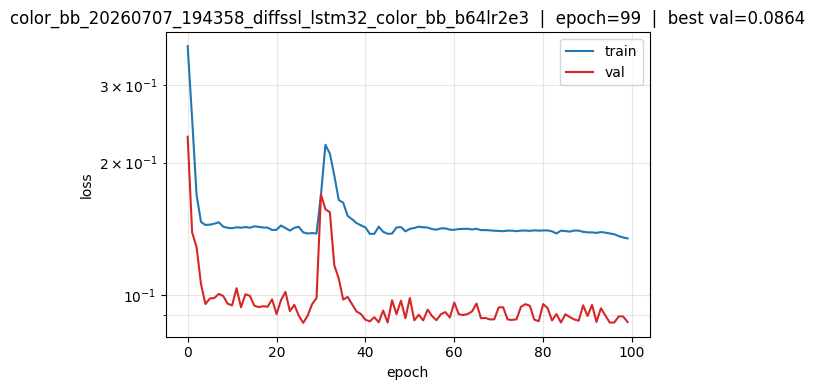

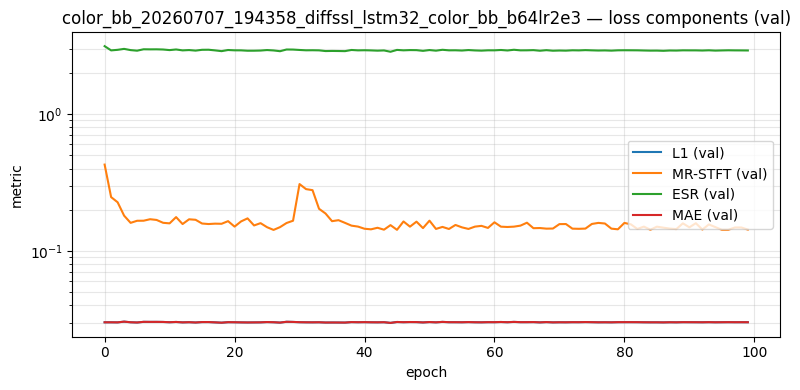

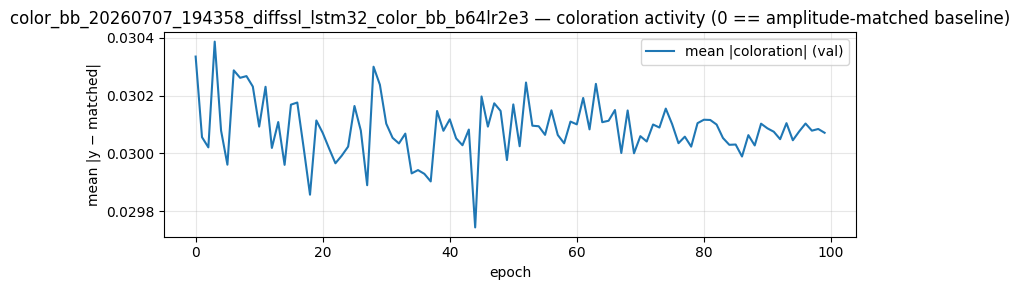

In [5]:
# ── 4. Loss curves (total + components + coloration activity) ────────

_ = plot_loss_curves(RUN_DIR)

csv_path = Path(RUN_DIR) / "csv" / "metrics.csv"
if csv_path.exists():
    _df = pd.read_csv(csv_path)

    comp_cols = [
        ("loss/val_td", "L1 (val)"),
        ("loss/val_fd", "MR-STFT (val)"),
        ("esr/val", "ESR (val)"),
        ("mae/val", "MAE (val)"),
    ]
    if any(c in _df.columns for c, _ in comp_cols):
        fig, ax = plt.subplots(figsize=(8, 4))
        for col, label in comp_cols:
            if col in _df.columns:
                rows = _df.dropna(subset=[col])[["epoch", col]]
                if len(rows):
                    ax.plot(rows["epoch"], rows[col], label=label, lw=1.5)
        ax.set_xlabel("epoch"); ax.set_ylabel("metric"); ax.set_yscale("log")
        ax.grid(alpha=0.3, which="both"); ax.legend()
        ax.set_title(f"{RUN_NAME} — loss components (val)")
        plt.tight_layout(); plt.show()

    # coloration activity: mean |y − matched|, the total learned coloration on top
    # of the pure amplitude-match multiply. (Δg is ≡ 0 for this model — no gain head —
    # so gain/val_delta_db is a flat 0 and is not plotted.)
    if "gain/val_color" in _df.columns:
        fig, ax = plt.subplots(figsize=(8, 3))
        rows = _df.dropna(subset=["gain/val_color"])[["epoch", "gain/val_color"]]
        if len(rows):
            ax.plot(rows["epoch"], rows["gain/val_color"], lw=1.5, color="#1f77b4",
                    label="mean |coloration| (val)")
        ax.set_xlabel("epoch"); ax.set_ylabel("mean |y − matched|"); ax.grid(alpha=0.3)
        ax.legend(loc="best")
        ax.set_title(f"{RUN_NAME} — coloration activity (0 == amplitude-matched baseline)")
        plt.tight_layout(); plt.show()


In [6]:
# ── 5. Checkpoint loading (ColorBlackboxLSTM) ────────────────────────

def load_model_from_ckpt(ckpt_path, hparams_path=None):
    # Build from hparams.json and load weights (strip Lightning 'model.' prefix).
    hparams_path = hparams_path or _find_hparams_json(ckpt_path)
    with open(hparams_path) as f:
        hp = json.load(f)
    assert hp.get("model_type") == MODEL_TYPE, hp.get("model_type")
    m = hp["model"]
    model = ColorBlackboxLSTM(
        num_controls=int(m["num_controls"]),
        hidden_size=int(m["hidden_size"]),
        num_layers=int(m["num_layers"]),
        tvcond_dim=int(m.get("tvcond_dim", 16)),
        cond_block_size=int(m.get("cond_block_size", 128)),
        cond_num_layers=int(m.get("cond_num_layers", 1)),
    )
    sd = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)["state_dict"]
    model.load_state_dict({k[len("model."):]: v for k, v in sd.items() if k.startswith("model.")})
    model.to(DEVICE).eval()
    n_params = sum(p.numel() for p in model.parameters())
    print(
        f"Loaded {n_params:,}-param ColorBlackboxLSTM  "
        f"(hidden={model.hidden_size}, controls={model.num_controls}, "
        f"cond_block={model.cond_block_size})"
    )
    return model, hp


MODEL, HP = load_model_from_ckpt(EVAL_CKPT_PATH, HPARAMS_PATH)
SR = int(HP["sample_rate"])
SAMPLE_LENGTH = int(HP.get("sample_length", 132300))
# GR derived from waveforms uses the same 1024-sample causal RMS window the
# exported gr_curves were built with.
RMS_WIN = int(HP.get("rms_window", RMS_WINDOW))


Loaded 8,033-param ColorBlackboxLSTM  (hidden=32, controls=4, cond_block=128)


In [7]:
# ── 6. Prediction & visualisation (stateful, coloration black-box) ────
# The model takes the amplitude-matched signal (x·10^(gr/20), formed internally
# from the raw dry + the sample-aligned GR curve) plus the 4 static knobs. A
# `pre_roll_sec` context is fed first (after reset_states) to warm the internal
# LSTM + tvcond states, then the segment is cropped out.
#
# Besides the waveform we recover a gain-reduction curve from the prediction
# (GR_pred = RMS_dB(pred) − RMS_dB(dry), the GR-bins definition) AND expose the
# model's own coloration: color = y − matched (the full residual the trunk adds on
# top of the pure multiply). matched = pred − color is the amplitude-match baseline
# the model started from (Δg / waveshaper are ≡ 0 for this model).

DEFAULT_PRE_ROLL_SEC = 10.0


def _wet_dir(setting: str) -> str:
    # processed_ground_truth (train/val settings) OR test_ground_truth (external
    # held-out settings). TEST_PAIRS live under the latter (v2 external policy),
    # so preview/sweep on a test pair resolves here — 8a/8b use their own paths.
    try:
        return wet_dir_for_setting(DATA_ROOT, setting)
    except FileNotFoundError:
        cand = os.path.join(DATA_ROOT, "test_ground_truth", setting)
        if os.path.isdir(cand):
            return cand
        raise


def pair_paths(setting: str, song: str) -> tuple[str, str, str]:
    dry = os.path.join(DATA_ROOT, "processed_normalized", f"{song}_UnmasteredWAV.wav")
    wet = os.path.join(_wet_dir(setting), f"{song}-exported.wav")
    gr = os.path.join(DATA_ROOT, "gr_curves", setting, f"{song}.pt")
    return dry, wet, gr


def _params_for(setting: str) -> torch.Tensor:
    # Normalised static knobs [1, num_controls] from the setting folder name.
    return torch.tensor(normalize_setting_params(setting), dtype=torch.float32,
                        device=DEVICE).unsqueeze(0)


def _load_gr_segment(gr_path: str, start: int, stop: int) -> torch.Tensor:
    gr_db = torch.load(gr_path, map_location="cpu", weights_only=False)["gr_db"].float()
    if gr_db.dim() == 1:
        gr_db = gr_db.unsqueeze(0)
    return gr_db[..., start:stop]


def _gr_from_audio(dry: torch.Tensor, sig: torch.Tensor) -> np.ndarray:
    # Gain reduction (dB) of `sig` relative to `dry`, clamped to the GR range.
    return (
        gain_reduction_db(dry, sig, RMS_WIN).clamp(GR_DB_MIN, GR_DB_MAX).squeeze().cpu().numpy()
    )


@torch.no_grad()
def predict_wet_segment(setting, song, start_sec=0.0, duration_sec=6.0,
                        pre_roll_sec=DEFAULT_PRE_ROLL_SEC, model=None):
    model = model or MODEL
    sr = SR
    dry_path, wet_path, gr_path = pair_paths(setting, song)

    start = int(round(start_sec * sr))
    stop = start + int(round(duration_sec * sr))
    context_start = max(0, start - int(round(pre_roll_sec * sr)))
    offset = start - context_start   # warm-up length

    dry_ctx, wet_ctx = _read_dry_wet_segment(dry_path, wet_path, context_start, stop, sr)
    gr_ctx = _load_gr_segment(gr_path, context_start, stop)
    n = min(dry_ctx.shape[-1], gr_ctx.shape[-1], wet_ctx.shape[-1])
    dry_ctx, gr_ctx, wet_ctx = dry_ctx[..., :n], gr_ctx[..., :n], wet_ctx[..., :n]
    params = _params_for(setting)

    model.reset_states()
    pred_full, _delta_full, color_full, _ws_full = model(
        dry_ctx.unsqueeze(0).to(DEVICE), gr_ctx.unsqueeze(0).to(DEVICE), params,
        return_parts_full=True)

    seg_len = min(stop - start, pred_full.shape[-1] - offset)
    sl = slice(offset, offset + seg_len)
    pred = pred_full[..., sl].squeeze(0).cpu()
    color = color_full[..., sl].squeeze(0).cpu()
    matched = pred - color                          # the amp-match baseline (Δg ≡ 0)
    wet = wet_ctx[..., sl].cpu()
    dry = dry_ctx[..., sl].cpu()
    gr_in = gr_ctx[..., sl].cpu()
    err = (pred - wet).squeeze().numpy()

    # Recover GR curves from the waveforms (same definition as the GR-bins model).
    gr_true = _gr_from_audio(dry, wet)
    gr_pred = _gr_from_audio(dry, pred)
    gr_err = gr_pred - gr_true

    t_len = pred.shape[-1]
    return {
        "song": song, "setting": setting,
        "sample_rate": sr, "start_sec": start_sec, "duration_sec": t_len / sr,
        "pre_roll_sec": offset / sr, "time": np.arange(t_len) / sr,
        "dry": dry.squeeze().numpy(),
        "wet": wet.squeeze().numpy(), "pred": pred.squeeze().numpy(),
        "matched": matched.squeeze().numpy(), "color": color.squeeze().numpy(),
        "error": err,
        "gr_in": gr_in.squeeze().numpy(),
        "gr_true": gr_true, "gr_pred": gr_pred, "gr_error": gr_err,
        "mae": float(np.mean(np.abs(err))),
        "esr": float(esr_metric(wet.unsqueeze(0), pred.unsqueeze(0))),
        "gr_mae_db": float(np.mean(np.abs(gr_err))),
        "gr_rmse_db": float(np.sqrt(np.mean(gr_err ** 2))),
        "color_mae": float(np.mean(np.abs(color.numpy()))),
    }


def visualize_prediction(setting=None, song=None, start_sec=30.0, duration_sec=6.0,
                         pre_roll_sec=DEFAULT_PRE_ROLL_SEC, title=None):
    song = song or TEST_PAIRS[0][0]
    setting = setting or TEST_PAIRS[0][1]
    seg = predict_wet_segment(setting, song, start_sec, duration_sec, pre_roll_sec)

    t = seg["time"]
    # rows: dry | waveform (wet/pred/matched) | wave err + coloration | GR (true/pred) | GR err
    fig, axes = plt.subplots(5, 1, figsize=(11, 13), sharex=True,
                             gridspec_kw={"height_ratios": [1, 2, 1, 2, 1]})

    axes[0].plot(t, seg["dry"], lw=0.6, color="#444")
    axes[0].set_ylabel("dry"); axes[0].set_ylim(-1.05, 1.05); axes[0].grid(alpha=0.3)

    axes[1].plot(t, seg["wet"], label="target (wet)", lw=1.0, color="#1f77b4")
    axes[1].plot(t, seg["pred"], label="prediction", lw=0.9, color="#d62728", alpha=0.85)
    axes[1].plot(t, seg["matched"], label="matched (x·10^(gr/20))", lw=0.6,
                 color="#7f7f7f", alpha=0.6)
    axes[1].set_ylabel("amp"); axes[1].legend(loc="lower right"); axes[1].set_ylim(-1.05, 1.05)
    axes[1].grid(alpha=0.3)

    # waveform error, with the learned coloration (pred − matched) overlaid — the
    # residual the SOTA trunk synthesises on top of the pure gain multiply.
    axes[2].plot(t, seg["error"], lw=0.8, color="#2ca02c", label="wave err")
    axes[2].plot(t, seg["color"], lw=0.7, color="#d62728", alpha=0.6,
                 label="coloration (pred − matched)")
    axes[2].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[2].set_ylabel("residual"); axes[2].legend(loc="lower right", fontsize=8)
    axes[2].grid(alpha=0.3)

    axes[3].plot(t, seg["gr_true"], label="target", lw=1.4, color="#1f77b4")
    axes[3].plot(t, seg["gr_pred"], label="prediction", lw=1.2, color="#d62728", alpha=0.85)
    axes[3].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[3].set_ylabel("GR (dB)"); axes[3].legend(loc="lower right"); axes[3].grid(alpha=0.3)

    axes[4].plot(t, seg["gr_error"], lw=0.8, color="#9467bd")
    axes[4].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[4].set_ylabel("GR err (dB)"); axes[4].set_xlabel("time (s)"); axes[4].grid(alpha=0.3)

    fig.suptitle(title or (
        f"{seg['song']}  |  {seg['setting']}\n"
        f"pre-roll={seg['pre_roll_sec']:.1f}s  "
        f"MAE {seg['mae']:.4f}  ESR {seg['esr']:.4f}  "
        f"GR MAE={seg['gr_mae_db']:.2f} dB  GR RMSE={seg['gr_rmse_db']:.2f} dB  "
        f"mean|color|={seg['color_mae']:.5f}"
    ), fontsize=10)
    plt.tight_layout(); plt.show()
    return seg


def _settings_for_song(song: str) -> list[str]:
    # The settings this song actually has a wet pair for (robust to both the old
    # and the v2 external-test split policies). Under v2, all_settings also lists
    # the 5 test_ground_truth-only settings, which exist only for their own test
    # songs — sweeping a val song through them would hit missing files.
    keys = (list(getattr(SPLIT, "train_pair_keys", []))
            + list(SPLIT.val_pair_keys) + list(SPLIT.test_pair_keys))
    ss = sorted({k.split("::")[1] for k in keys if k.split("::")[0] == song})
    return ss or [s for s in SPLIT.all_settings if s not in set(SPLIT.test_settings)]


def settings_sweep(song=None, settings=None, start_sec=30.0, duration_sec=6.0,
                   pre_roll_sec=DEFAULT_PRE_ROLL_SEC):
    # Same song through every setting it has - generalisation across knobs.
    # Compares the gain-reduction curves (target vs prediction) per setting.
    song = song or SPLIT.val_songs[0]
    settings = settings or _settings_for_song(song)
    segs = [predict_wet_segment(s, song, start_sec, duration_sec, pre_roll_sec) for s in settings]

    fig, axes = plt.subplots(len(segs), 1, figsize=(11, 1.8 * len(segs)),
                             sharex=True, sharey=True, squeeze=False)
    for ax, s in zip(axes[:, 0], segs):
        ax.plot(s["time"], s["gr_true"], lw=1.4, color="#1f77b4", label="target")
        ax.plot(s["time"], s["gr_pred"], lw=1.2, color="#d62728", alpha=0.85, label="prediction")
        ax.axhline(0, color="k", lw=0.5, alpha=0.4)
        ax.set_ylabel("GR (dB)", fontsize=8)
        ax.set_title(
            f"{s['setting']}  —  GR MAE {s['gr_mae_db']:.2f} dB  "
            f"MAE {s['mae']:.4f}  ESR {s['esr']:.4f}  mean|color| {s['color_mae']:.5f}",
            fontsize=8, loc="left",
        )
        ax.grid(alpha=0.3)
    axes[0, 0].legend(loc="lower right", fontsize=8)
    axes[-1, 0].set_xlabel("time (s)")
    fig.suptitle(f"Settings sweep — GR curves — {song} ({duration_sec:.0f}s @ {start_sec:.0f}s)",
                 fontsize=11)
    plt.tight_layout(); plt.show()

    df = pd.DataFrame([
        {
            "setting": s["setting"],
            "GR MAE (dB)": s["gr_mae_db"],
            "MAE": s["mae"],
            "ESR": s["esr"],
            "mean |color|": s["color_mae"],
        }
        for s in segs
    ])
    display(df)
    return segs, df


## Usage

Re-run the cells below any time; they read the latest synced files from Drive.
Use the available-runs cell first, then set `SELECTED_RUN_NAME` in the selection cell.

- `visualize_prediction(setting=..., song=...)` — any (setting, song); defaults to the first **test** pair. Shows the waveform (target / prediction / the amplitude-matched baseline the model starts from), the gain-reduction curve recovered from the prediction, and the **learned coloration** `pred − matched` (the residual the SOTA trunk synthesises on top of the pure gain multiply).
- `settings_sweep(song=...)` — one song through all 10 settings (defaults to the val song). Plots the GR-curve comparison per setting; the table adds `mean |color|`.
- `coloration_spectra(setting=..., song=...)` is the reason this model exists: it overlays the PSDs of the *target* coloration (`wet − matched`) and the *learned* coloration (`pred − matched`) — overlap above ~300 Hz (where the additive gain-prior runs left the residual untouched) is the win condition.
- The split metrics cell scores the **validation** split on the canonical 9-column engine ported from [`02b_sota_training/eval_lstm_diffssl_tvc.ipynb`](../02b_sota_training/eval_lstm_diffssl_tvc.ipynb), so numbers are directly comparable across models.
- The test section scores the **held-out test set** (`test_ground_truth/`, 5 fully-unseen song×setting pairs) with the same engine. Its GR curves are already exported — 8a only verifies and loads them.
- **Section 9** runs the GR-source ablations (oracle / predicted / const_mean / const_0db / amp_match) on **2 validation pairs** (`ABLATION_PAIRS`) — since gain is applied by the input multiply, this measures how sensitive the coloration trunk is to the GR trajectory it is handed. `amp_match` is the no-NN multiply baseline scored with the identical engine.


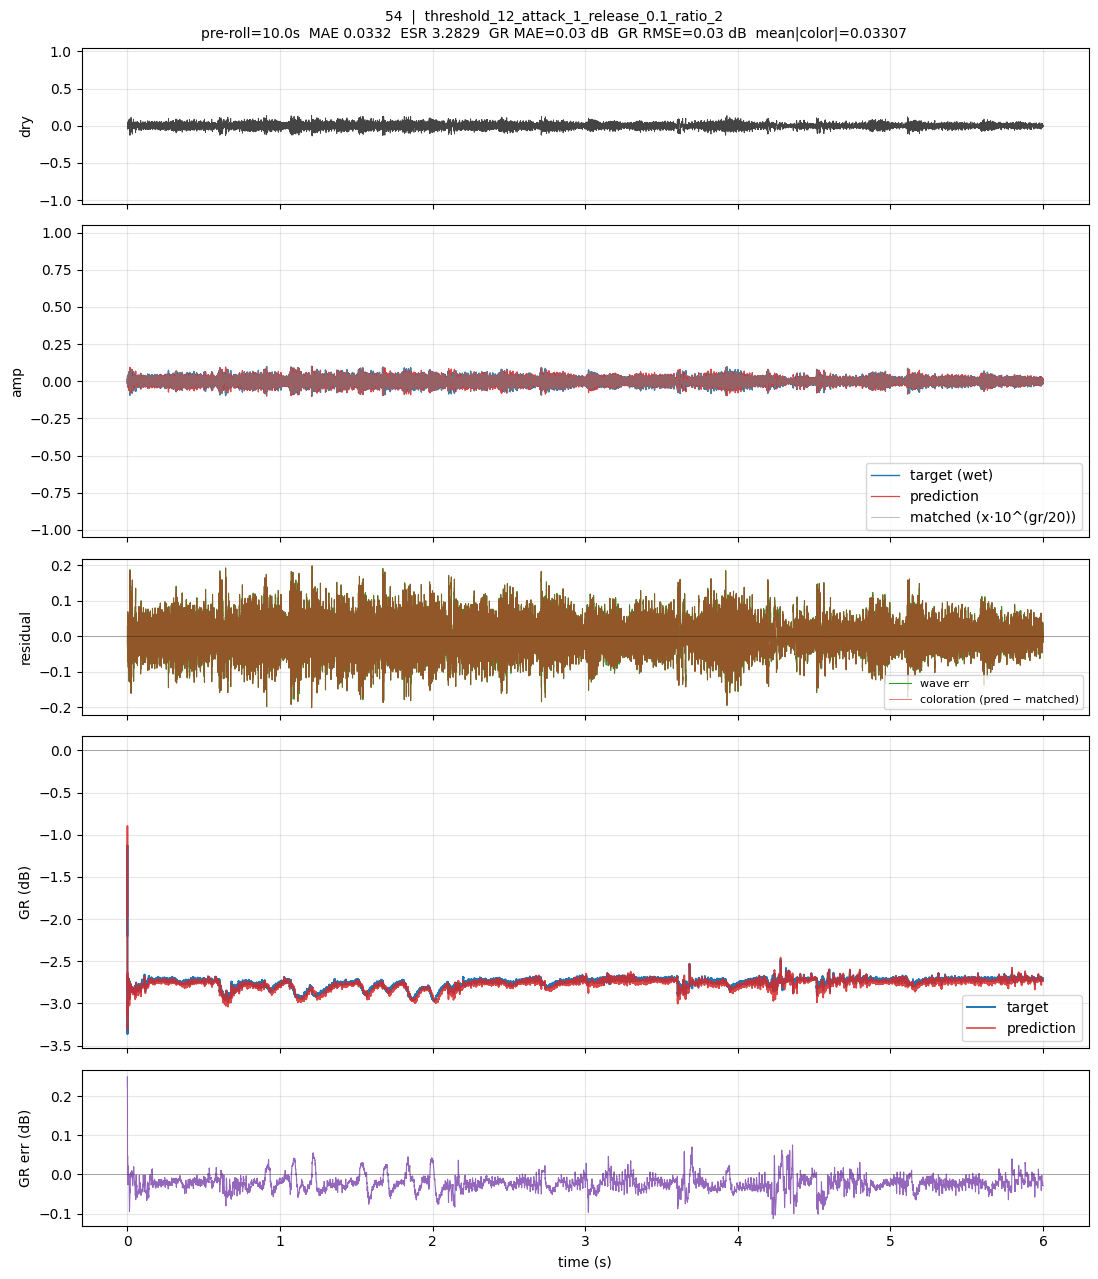

In [8]:
# Single prediction preview — held-out test song x lowest-threshold setting
song, setting = TEST_PAIRS[0]
_ = visualize_prediction(setting=setting, song=song, start_sec=30.0, duration_sec=6.0)

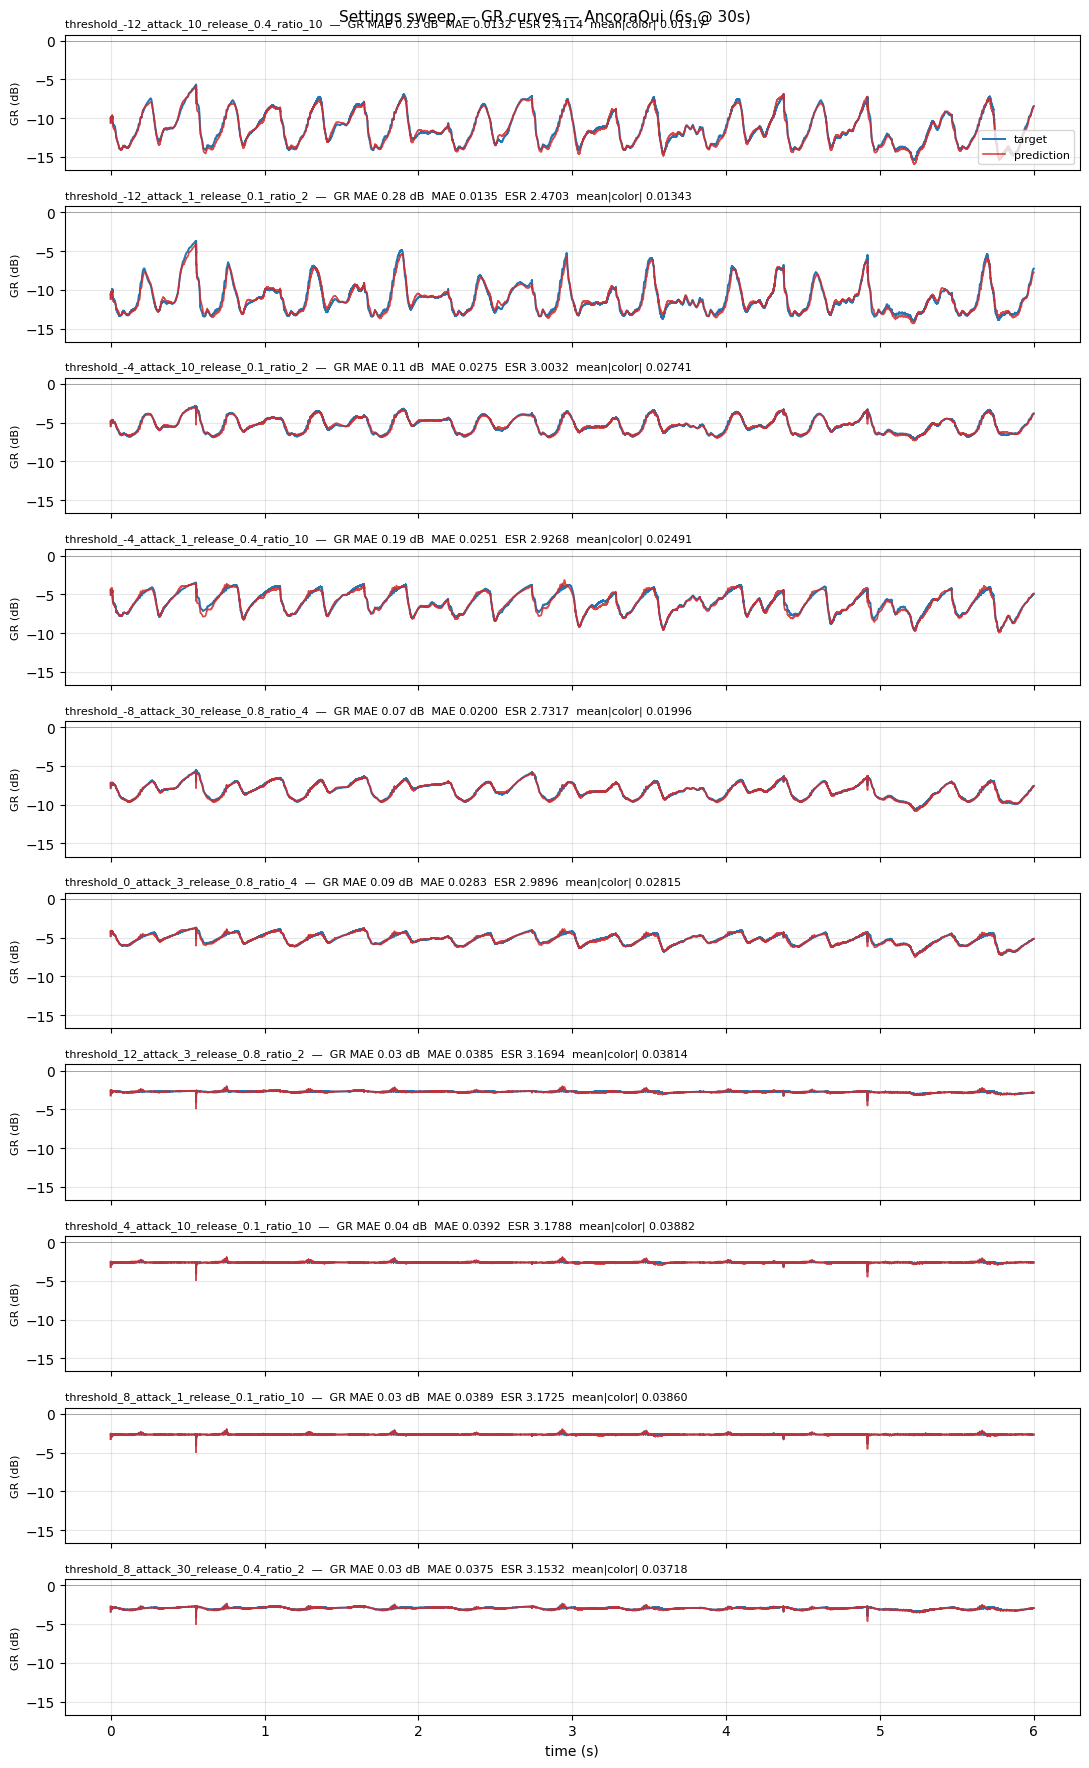

,setting,GR MAE (dB),MAE,ESR,mean |color|
0,threshold_-12_attack_10_release_0.4_ratio_10,0.225487,0.013192,2.411440,0.013170
1,threshold_-12_attack_1_release_0.1_ratio_2,0.276530,0.013503,2.470331,0.013429
2,threshold_-4_attack_10_release_0.1_ratio_2,0.113094,0.027530,3.003196,0.027414
3,threshold_-4_attack_1_release_0.4_ratio_10,0.192101,0.025073,2.926762,0.024906
4,threshold_-8_attack_30_release_0.8_ratio_4,0.072824,0.020028,2.731709,0.019958
5,threshold_0_attack_3_release_0.8_ratio_4,0.087807,0.028327,2.989597,0.028148
6,threshold_12_attack_3_release_0.8_ratio_2,0.034459,0.038467,3.169419,0.038139
7,threshold_4_attack_10_release_0.1_ratio_10,0.036344,0.039160,3.178806,0.038816
8,threshold_8_attack_1_release_0.1_ratio_10,0.025229,0.038941,3.172456,0.038596
9,threshold_8_attack_30_release_0.4_ratio_2,0.028638,0.037486,3.153240,0.037179


In [9]:
# Settings sweep: validation song through all 10 settings
sweep_segs, sweep_df = settings_sweep(start_sec=30.0, duration_sec=6.0)

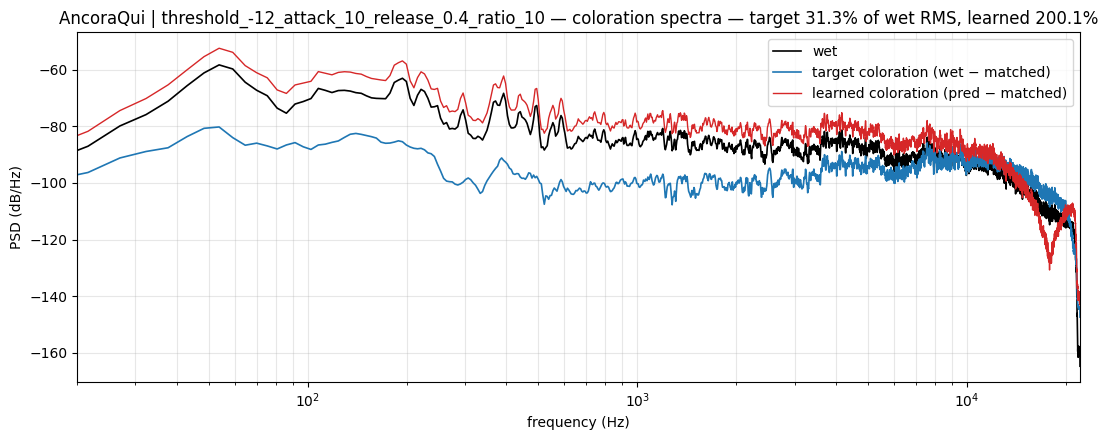

In [10]:
# ── 6c. Learned coloration spectra — the reason this model exists ─────
# Additive gain-prior runs left the matched→wet residual untouched above ~300 Hz;
# this model hands that residual to the SOTA trunk. Compare PSDs of the TARGET
# coloration (wet − matched) and the LEARNED coloration (pred − matched == color)
# on a segment. Overlap above ~300 Hz is the win condition; the RMS shares report
# each coloration's magnitude relative to the wet signal.

from scipy.signal import welch


def coloration_spectra(setting=None, song=None, start_sec=30.0, duration_sec=6.0,
                       pre_roll_sec=DEFAULT_PRE_ROLL_SEC, nperseg=8192):
    song = song or SPLIT.val_songs[0]
    setting = setting or SPLIT.all_settings[0]
    seg = predict_wet_segment(setting, song, start_sec, duration_sec, pre_roll_sec)

    wet = seg["wet"]
    tgt_col = wet - seg["matched"]
    lrn_col = seg["color"]                          # == pred − matched

    fig, ax = plt.subplots(figsize=(11, 4.5))
    for sig, name, style in ((wet, "wet", dict(color="k", lw=1.2)),
                             (tgt_col, "target coloration (wet − matched)",
                              dict(color="#1f77b4", lw=1.2)),
                             (lrn_col, "learned coloration (pred − matched)",
                              dict(color="#d62728", lw=1.0))):
        f, Pxx = welch(sig, fs=SR, nperseg=min(nperseg, len(sig)))
        ax.semilogx(f, 10 * np.log10(Pxx + 1e-18), label=name, **style)
    rms = lambda v: float(np.sqrt(np.mean(v ** 2)))
    ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("PSD (dB/Hz)")
    ax.set_title(f"{seg['song']} | {seg['setting']} — coloration spectra — "
                 f"target {rms(tgt_col) / rms(wet):.1%} of wet RMS, "
                 f"learned {rms(lrn_col) / rms(wet):.1%}")
    ax.grid(alpha=0.3, which="both"); ax.legend(); ax.set_xlim(20, SR / 2)
    plt.tight_layout(); plt.show()
    return seg


_ = coloration_spectra(start_sec=30.0, duration_sec=6.0)


In [11]:
# ── 6b. Metric engine (ported from 02b_sota_training/eval_lstm_diffssl_tvc.ipynb) ──
#
# The canonical 9-column table so this model drops straight into the cross-model
# comparison. Every moving-average envelope uses an O(N) cumsum window; the FFT
# metrics reimplement auraloss MultiResolutionSTFTLoss and src.losses.{M_SF, EDC},
# batched. MR-STFT and ESR are verified below against nablafx.evaluation (auraloss)
# to <1e-3 / <1e-4.

from scipy.signal import bilinear, lfilter

EPS = 1e-10

# Multi-resolution window / FFT sets (identical to the diffssl_tvc engine)
MR_STE_WINDOWS   = (256, 1024, 4096)                     # short-time energy (envelope shape)
MR_NRMSE_WINDOWS = (512, 1024, 2048)                     # == src.losses.multi_resolution_nrmse
STFT_SIZES       = (512, 1024, 2048)                     # spectral-flux resolutions
_MRSTFT_RES      = [(1024, 120, 600), (2048, 240, 1200), (512, 50, 240)]   # auraloss defaults

# Final metric columns: GR-stage | colour-stage | standard
METRIC_COLS = [
    "GR MAE (dB)", "MR-STE",                             # GR stage
    "MR-STFT", "ESR (A-wt)",                             # colour stage (auraloss MR-STFT + A-weighted ESR)
    "MAE (L1)", "MSE (L2)", "EDC", "M_NRMSE", "M_SF",    # standard
]


# ── moving-average envelopes (cumsum: O(N), window-independent) ──
def _moving_meansq(x_sq, W, centered):
    """Sliding mean of x**2 via prefix sums. centered=symmetric, else causal (trailing)."""
    n = x_sq.shape[-1]
    c = np.empty(n + 1); c[0] = 0.0; np.cumsum(x_sq, out=c[1:])
    i = np.arange(n)
    if centered:
        lo = i - (W // 2); hi = lo + W
    else:                                                # causal == src.dsp_torch.gain_reduction_db
        hi = i + 1; lo = hi - W
    lo = np.clip(lo, 0, n); hi = np.clip(hi, 0, n)
    return (c[hi] - c[lo]) / np.maximum(hi - lo, 1)

def _to_db(x):       return 20.0 * np.log10(np.maximum(x, EPS))
def _esr(pred, tgt): return float(np.sum((tgt - pred) ** 2) / (np.sum(tgt * tgt) + 1e-8))

# A-weighting IIR (analog prototype -> bilinear) for the A-weighted ESR
def _a_weighting_ba(fs):
    f1, f2, f3, f4 = 20.598997, 107.65265, 737.86223, 12194.217
    A1000 = 1.9997
    nums = [(2 * np.pi * f4) ** 2 * 10 ** (A1000 / 20.0), 0, 0, 0, 0]
    dens = np.polymul([1, 4 * np.pi * f4, (2 * np.pi * f4) ** 2],
                      [1, 4 * np.pi * f1, (2 * np.pi * f1) ** 2])
    dens = np.polymul(np.polymul(dens, [1, 2 * np.pi * f3]), [1, 2 * np.pi * f2])
    return bilinear(nums, dens, fs)
AW_B, AW_A = _a_weighting_ba(SR)


def reference_gr_db(dry, wet, W=RMS_WIN):
    """Reference GR trajectory = causal RMS GR (matches src.dsp_torch.gain_reduction_db)."""
    return (_to_db(np.sqrt(_moving_meansq(wet * wet, W, centered=False)))
            - _to_db(np.sqrt(_moving_meansq(dry * dry, W, centered=False))))


# ── GR-stage / envelope metrics ──
def mr_ste(pred, wet, windows=MR_STE_WINDOWS):
    """Multi-resolution short-time energy distance (envelope shape; Wright & Valimaki)."""
    pe, we = pred * pred, wet * wet
    total = 0.0
    for W in windows:
        ep = _moving_meansq(pe, W, centered=True)
        et = _moving_meansq(we, W, centered=True)
        total += np.sum(np.abs(ep - et)) / (np.sum(np.abs(et)) + 1e-8)
    return float(total / len(windows))

def mr_nrmse(pred, wet, windows=MR_NRMSE_WINDOWS):
    """Mean normalised RMS-envelope error (== src.losses.multi_resolution_nrmse, cumsum-fast)."""
    total = 0.0
    for W in windows:
        rp = np.sqrt(_moving_meansq(pred * pred, W, centered=False))
        rt = np.sqrt(_moving_meansq(wet * wet, W, centered=False))
        total += np.sqrt(np.mean((rt - rp) ** 2)) / (np.sqrt(np.mean(rt * rt)) + 1e-8)
    return float(total / len(windows))


# ── colour-stage + standard FFT metrics ──
_HANN = {}
def _win(n):
    if n not in _HANN:
        _HANN[n] = torch.hann_window(n)
    return _HANN[n]

def _stft_mag_pow(x2d, n_fft, hop, win):
    """auraloss-style magnitude = sqrt(clamp(re^2 + im^2, 1e-8))."""
    st = torch.stft(x2d, n_fft=n_fft, hop_length=hop, win_length=win,
                    window=_win(win), return_complex=True)
    return torch.sqrt(torch.clamp(st.real ** 2 + st.imag ** 2, min=1e-8))

def _stft_mag_fft(x2d, n_fft):
    """src.losses-style magnitude (hop = n_fft // 4, hann(n_fft))."""
    return torch.stft(x2d, n_fft=n_fft, hop_length=n_fft // 4,
                      window=_win(n_fft), return_complex=True).abs()

@torch.no_grad()
def fft_metrics(pred1d: torch.Tensor, wet1d: torch.Tensor) -> dict:
    """auraloss MR-STFT + src.losses {M_SF, EDC} for one (pred, wet) pair."""
    P1, T1 = pred1d.unsqueeze(0), wet1d.unsqueeze(0)
    out = {}

    # MR-STFT (auraloss default = spectral-convergence + log-magnitude, mean over 3 resolutions)
    acc = 0.0
    for n_fft, hop, win in _MRSTFT_RES:
        P = _stft_mag_pow(P1, n_fft, hop, win)[0]
        T = _stft_mag_pow(T1, n_fft, hop, win)[0]
        sc = torch.linalg.norm(T - P) / torch.linalg.norm(T)
        lm = (torch.log(P) - torch.log(T)).abs().mean()
        acc += float(sc + lm)
    out["MR-STFT"] = acc / len(_MRSTFT_RES)

    # spectral-flux (M_SF) over (512, 1024, 2048)
    sf = 0.0
    for n_fft in STFT_SIZES:
        P = _stft_mag_fft(P1, n_fft)[0]
        T = _stft_mag_fft(T1, n_fft)[0]
        pf, tf = torch.diff(P, dim=-1), torch.diff(T, dim=-1)
        sf += float((tf - pf).abs().mean() / (tf.abs().mean() + 1e-8))
    out["M_SF"] = sf / len(STFT_SIZES)

    # EDC (energy-decay-curve error, dB)
    pe = torch.flip(torch.cumsum(torch.flip(P1 ** 2, dims=(-1,)), dim=-1), dims=(-1,))
    te = torch.flip(torch.cumsum(torch.flip(T1 ** 2, dims=(-1,)), dim=-1), dims=(-1,))
    pe = pe / (pe[..., :1] + 1e-8); te = te / (te[..., :1] + 1e-8)
    out["EDC"] = float((10 * torch.log10(te.clamp(min=1e-8))
                        - 10 * torch.log10(pe.clamp(min=1e-8))).abs().mean())
    return out


def chunk_metrics(dry: np.ndarray, pred: np.ndarray, wet: np.ndarray) -> dict:
    """The 9 metric columns for one (dry, pred, wet) chunk (float64 1-D arrays).

    GR MAE compares the prediction's causal-RMS GR against the reference RMS
    GR(dry, wet), both clamped to [GR_DB_MIN, GR_DB_MAX]. FFT metrics run in float32.
    """
    gr_tgt  = np.clip(reference_gr_db(dry, wet),  GR_DB_MIN, GR_DB_MAX)
    gr_pred = np.clip(reference_gr_db(dry, pred), GR_DB_MIN, GR_DB_MAX)
    row = {
        "GR MAE (dB)": float(np.mean(np.abs(gr_pred - gr_tgt))),
        "MR-STE":      mr_ste(pred, wet),
        "ESR (A-wt)":  _esr(lfilter(AW_B, AW_A, pred), lfilter(AW_B, AW_A, wet)),
        "MAE (L1)":    float(np.mean(np.abs(pred - wet))),
        "MSE (L2)":    float(np.mean((pred - wet) ** 2)),
        "M_NRMSE":     mr_nrmse(pred, wet),
    }
    row.update(fft_metrics(torch.from_numpy(pred).float(),
                           torch.from_numpy(wet).float()))
    return row


# ── verify MR-STFT / ESR against nablafx.evaluation (auraloss) ──
try:
    from nablafx.evaluation import get_function
    _g = torch.Generator().manual_seed(0)
    _p = torch.randn(SR, generator=_g); _t = torch.randn(SR, generator=_g)
    _nab_mrstft, _nab_esr = get_function("mrstft_loss"), get_function("esr_loss")
    _pt, _tt = _p.view(1, 1, -1), _t.view(1, 1, -1)
    _fm = fft_metrics(_p, _t)
    _d_mrstft = abs(float(_nab_mrstft(_pt, _tt)) - _fm["MR-STFT"])
    _d_esr = abs(float(_nab_esr(_pt, _tt)) - _esr(_p.double().numpy(), _t.double().numpy()))
    assert _d_mrstft < 1e-3, _d_mrstft
    assert _d_esr < 1e-4, _d_esr
    print(f"nablafx.evaluation verified — MR-STFT Δ={_d_mrstft:.2e}, ESR Δ={_d_esr:.2e}")
except Exception as e:
    print(f"nablafx verification skipped: {e}")

print(f"Metric engine registered — {len(METRIC_COLS)} columns: {METRIC_COLS}")

nablafx.evaluation verified — MR-STFT Δ=0.00e+00, ESR Δ=5.61e-08
Metric engine registered — 9 columns: ['GR MAE (dB)', 'MR-STE', 'MR-STFT', 'ESR (A-wt)', 'MAE (L1)', 'MSE (L2)', 'EDC', 'M_NRMSE', 'M_SF']


In [ ]:
# ── 7. Audio metrics on the VALIDATION split (TRUE stateful streaming) ──
# Streams each (song, setting) validation pair whole-song in NON-overlapping chunks
# with all internal LSTM states carried across chunks (matching TBPTT training):
# the main LSTM + the tvcond generator. reset_states() once per pair,
# detach_states() between chunks. The raw dry, the 4 static knobs, and the
# GR curve are fed for each chunk. Chunk length is snapped to a multiple of the
# tvcond block (128). Each chunk is scored with the ported metric engine
# (chunk_metrics) — the SAME 9-column table as eval_lstm_diffssl_tvc.ipynb, results
# duration-weighted.

MAX_EVAL_PAIRS: int | None = None    # small int for a smoke test
STREAM_CHUNK_SEC = 10.0
SAVE_CHUNK_METRICS = False
MIN_METRIC_FRAMES = max(STFT_SIZES)  # skip sub-FFT tail chunks (torch.stft needs >= n_fft)

sr = SR
_BLOCK = int(HP["model"].get("cond_block_size", 128))
# snap chunk length to a whole number of conditioning blocks
chunk_samples = max(_BLOCK, (int(round(STREAM_CHUNK_SEC * sr)) // _BLOCK) * _BLOCK)


@torch.no_grad()
def stream_pair_metrics(song: str, setting: str) -> list[dict]:
    # Stateful pass over a whole (song, setting) pair; per-chunk metric rows.
    dry_path, wet_path, gr_path = pair_paths(setting, song)
    total = _pair_num_frames(dry_path, wet_path, sr)
    gr_full = torch.load(gr_path, map_location="cpu", weights_only=False)["gr_db"].float()
    if gr_full.dim() == 1:
        gr_full = gr_full.unsqueeze(0)
    params = _params_for(setting)

    MODEL.reset_states()
    rows = []
    for ci, o in enumerate(range(0, total, chunk_samples), start=1):
        stop = min(o + chunk_samples, total)
        dry, wet = _read_dry_wet_segment(dry_path, wet_path, o, stop, sr)
        gr = gr_full[..., o:stop]
        n = min(dry.shape[-1], gr.shape[-1], wet.shape[-1])
        if n == 0:
            break
        dry, gr, wet = dry[..., :n], gr[..., :n], wet[..., :n]

        pred = MODEL(dry.unsqueeze(0).to(DEVICE), gr.unsqueeze(0).to(DEVICE), params)
        MODEL.detach_states()
        if n < MIN_METRIC_FRAMES:                       # too short for the largest STFT
            continue

        # float64 1-D arrays for the ported metric engine (FFT metrics run in float32).
        d = dry.squeeze(0).double().cpu().numpy()
        w = wet.squeeze(0).double().cpu().numpy()
        p = pred.squeeze().double().cpu().numpy()
        rows.append({"Chunk": ci, "Start (s)": o / sr, "Duration (s)": n / sr, "Frames": n,
                     **chunk_metrics(d, p, w)})
    return rows


val_pairs = VAL_PAIRS if MAX_EVAL_PAIRS is None else VAL_PAIRS[:MAX_EVAL_PAIRS]
chunk_rows, pair_rows = [], []
for i, (song, setting) in enumerate(val_pairs, start=1):
    print(f"[validation {i}/{len(val_pairs)}] {song} / {setting}")
    rows = stream_pair_metrics(song, setting)
    chunk_rows += [{"Song": song, "Setting": setting, **r} for r in rows]
    pair_rows.append({
        "Split": "validation", "Song": song, "Setting": setting,
        "Duration (s)": sum(r["Frames"] for r in rows) / sr,
        **_weighted_average_metric_rows(rows, METRIC_COLS),
    })
    gc.collect()

total_frames = sum(r["Frames"] for r in chunk_rows)
split_row = {
    "Split": "validation", "Pairs": len(val_pairs), "Chunks": len(chunk_rows),
    "Duration (s)": total_frames / sr,
    **_weighted_average_metric_rows(chunk_rows, METRIC_COLS),
}

pair_metrics_df = pd.DataFrame(pair_rows)
audio_metrics_df = pd.DataFrame([split_row])
pair_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_validation_pairs.csv", index=False)
audio_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_validation.csv", index=False)
if SAVE_CHUNK_METRICS:
    pd.DataFrame(chunk_rows).to_csv(
        Path(RUN_DIR) / "eval_audio_metrics_validation_chunks.csv", index=False)
print(f"Saved -> {RUN_DIR}/eval_audio_metrics_validation(.csv, _pairs.csv)")

display(pair_metrics_df)
display(audio_metrics_df)

[validation 1/10] AncoraQui / threshold_-12_attack_10_release_0.4_ratio_10
[validation 2/10] AncoraQui / threshold_-12_attack_1_release_0.1_ratio_2


## Held-out TEST set (`test_ground_truth`)

Final generalisation check on the **external held-out test set** in
`Diff-SSL-G-Comp/test_ground_truth/` — 5 `(song, setting)` pairs whose **songs
*and* compressor settings were never seen during training** (e.g.
`IncidenteEnIntag @ threshold_-12_attack_1_release_0.8_ratio_2`). This is
separate from `SPLIT.test_pair_keys` (those held-out `processed_ground_truth`
pairs remain unscored); it is the harder, fully-unseen test.

Two cells:

- **8a — load GR curves.** The GR curves for these unseen settings were already
  exported once with the canonical exporter
  (`03_initial_GR_pred/gr_dataset.py::export_pair`) — the exact same code and
  format (raw dB, 1024-sample causal RMS) as the training/validation curves,
  written to `gr_curves/<setting>/<song>.pt`. Nothing is re-exported here: the
  cell discovers the `(song, setting)` pairs and verifies every `.pt` exists.
- **8b — metrics.** Scores the test set with the **exact same** stateful
  whole-song streaming and canonical 9-column engine as the validation cell,
  loading the exported `.pt` and slicing it exactly like the validation path.
  Results are written to `eval_audio_metrics_test(.csv, _pairs.csv)` alongside
  the validation CSVs.


In [ ]:
# ── 8a. Held-out test pairs — load the already-exported GR curves ───
# The GR curves for these unseen test settings were exported ONCE with the
# canonical exporter (03_initial_GR_pred/gr_dataset.py::export_pair — raw dB,
# 1024-sample causal RMS) to gr_curves/<setting>/<song>.pt, identical in code,
# method and format to the training/validation curves. Nothing is re-exported
# here: discover the (song, setting) pairs and verify every .pt exists, so the
# test eval below can load and slice them exactly like the validation path.

TEST_GT_DIR = os.path.join(DATA_ROOT, "test_ground_truth")


def discover_test_pairs(test_gt_dir: str = TEST_GT_DIR) -> list[tuple[str, str]]:
    # (song, setting) pairs under test_ground_truth that have a dry match.
    dry_dir = os.path.join(DATA_ROOT, "processed_normalized")
    pairs, missing = [], []
    for setting in sorted(os.listdir(test_gt_dir)):
        sdir = os.path.join(test_gt_dir, setting)
        if not os.path.isdir(sdir) or setting.startswith("."):
            continue
        for wet in sorted(glob.glob(os.path.join(sdir, "*-exported.wav"))):
            song = os.path.basename(wet).replace("-exported.wav", "")
            dry = os.path.join(dry_dir, f"{song}_UnmasteredWAV.wav")
            (pairs if os.path.isfile(dry) else missing).append((song, setting))
    if missing:
        print(f"[warning] {len(missing)} test wet files have no dry match (skipped): {missing}")
    return pairs


def test_pair_paths(setting: str, song: str) -> tuple[str, str, str]:
    dry = os.path.join(DATA_ROOT, "processed_normalized", f"{song}_UnmasteredWAV.wav")
    wet = os.path.join(TEST_GT_DIR, setting, f"{song}-exported.wav")
    gr = os.path.join(DATA_ROOT, "gr_curves", setting, f"{song}.pt")
    return dry, wet, gr


NEW_TEST_PAIRS = discover_test_pairs()
print(f"Held-out test pairs (test_ground_truth): {len(NEW_TEST_PAIRS)}")

_missing_gr = []
for song, setting in NEW_TEST_PAIRS:
    gr_path = test_pair_paths(setting, song)[2]
    if os.path.isfile(gr_path):
        print(f"  exists {os.path.relpath(gr_path, DATA_ROOT)}")
    else:
        _missing_gr.append(gr_path)
assert not _missing_gr, (
    f"{len(_missing_gr)} GR curve(s) missing — export them once with "
    f"03_initial_GR_pred/gr_dataset.py::export_pair: {_missing_gr}"
)


In [ ]:
# ── 8b. Audio metrics on the held-out TEST set (test_ground_truth) ───
# Byte-for-byte the same as the VALIDATION streaming cell (── 7): stateful
# whole-song streaming in block-aligned chunks, all internal LSTM states carried
# across chunks (main LSTM + tvcond), reset_states() once per pair,
# detach_states() between chunks, scored with the SAME 9-column engine and
# duration-weighted. Only the pair source differs: wet from test_ground_truth/
# and the GR curve from the .pt exported in 8a (songs AND settings unseen in
# training — true generalisation).

@torch.no_grad()
def stream_test_pair_metrics(song: str, setting: str) -> list[dict]:
    # Stateful pass over a whole (song, setting) TEST pair; per-chunk metric rows.
    dry_path, wet_path, gr_path = test_pair_paths(setting, song)
    total = _pair_num_frames(dry_path, wet_path, sr)
    gr_full = torch.load(gr_path, map_location="cpu", weights_only=False)["gr_db"].float()
    if gr_full.dim() == 1:
        gr_full = gr_full.unsqueeze(0)
    params = _params_for(setting)

    MODEL.reset_states()
    rows = []
    for ci, o in enumerate(range(0, total, chunk_samples), start=1):
        stop = min(o + chunk_samples, total)
        dry, wet = _read_dry_wet_segment(dry_path, wet_path, o, stop, sr)
        gr = gr_full[..., o:stop]
        n = min(dry.shape[-1], gr.shape[-1], wet.shape[-1])
        if n == 0:
            break
        dry, gr, wet = dry[..., :n], gr[..., :n], wet[..., :n]

        pred = MODEL(dry.unsqueeze(0).to(DEVICE), gr.unsqueeze(0).to(DEVICE), params)
        MODEL.detach_states()
        if n < MIN_METRIC_FRAMES:                       # too short for the largest STFT
            continue

        # float64 1-D arrays for the ported metric engine (FFT metrics run in float32).
        d = dry.squeeze(0).double().cpu().numpy()
        w = wet.squeeze(0).double().cpu().numpy()
        p = pred.squeeze().double().cpu().numpy()
        rows.append({"Chunk": ci, "Start (s)": o / sr, "Duration (s)": n / sr, "Frames": n,
                     **chunk_metrics(d, p, w)})
    return rows


test_chunk_rows, test_pair_rows = [], []
for i, (song, setting) in enumerate(NEW_TEST_PAIRS, start=1):
    print(f"[test {i}/{len(NEW_TEST_PAIRS)}] {song} / {setting}")
    rows = stream_test_pair_metrics(song, setting)
    test_chunk_rows += [{"Song": song, "Setting": setting, **r} for r in rows]
    test_pair_rows.append({
        "Split": "test", "Song": song, "Setting": setting,
        "Duration (s)": sum(r["Frames"] for r in rows) / sr,
        **_weighted_average_metric_rows(rows, METRIC_COLS),
    })
    gc.collect()

test_total_frames = sum(r["Frames"] for r in test_chunk_rows)
test_split_row = {
    "Split": "test", "Pairs": len(NEW_TEST_PAIRS), "Chunks": len(test_chunk_rows),
    "Duration (s)": test_total_frames / sr,
    **_weighted_average_metric_rows(test_chunk_rows, METRIC_COLS),
}

test_pair_metrics_df = pd.DataFrame(test_pair_rows)
test_audio_metrics_df = pd.DataFrame([test_split_row])
test_pair_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_test_pairs.csv", index=False)
test_audio_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_test.csv", index=False)
if SAVE_CHUNK_METRICS:
    pd.DataFrame(test_chunk_rows).to_csv(
        Path(RUN_DIR) / "eval_audio_metrics_test_chunks.csv", index=False)
print(f"Saved -> {RUN_DIR}/eval_audio_metrics_test(.csv, _pairs.csv)")

display(test_pair_metrics_df)
display(test_audio_metrics_df)

## 9. Conditioning ablations — how sensitive is the coloration trunk to the GR it is handed? (no training)

Gain enters this model **only** through the input multiply `matched = x·10^(gr/20)`
— the trunk never sees the GR value, so it applies whatever GR trajectory it is
handed exactly. Everything above used the **oracle** GR (computed from the wet
target — unavailable at deployment). These no-training ablations swap the GR source
and re-stream the SAME checkpoint through the SAME 9-column engine:

| Variant | GR source | What it measures |
|---|---|---|
| `oracle` | `gr_curves/*.pt` (from wet) | upper bound (the numbers above) |
| `predicted` | `05_conditioning` predictor on dry + knobs | **the deployable number** — the honest, wet-free result |
| `const_mean` | per-pair mean of the oracle GR | static gain with the right average — isolates the value of the GR's *temporal* information |
| `const_0db` | 0 dB everywhere | `matched = dry`, so `y = tanh(lin(LSTM(dry, tvcond)))` — the model degenerates to the from-scratch SOTA black-box (no compression applied) |
| `amp_match` | oracle GR, **model bypassed** | `dry × 10^(gr/20)` scored with the identical engine — the pure multiply with no coloration; the trained trunk must beat this to justify itself |

Reading the table: `oracle → predicted` is the **deployment gap** (predictor
quality is the bottleneck if this is large); `oracle → const_mean` is the
**temporal-information contribution**; `oracle vs amp_match` is the coloration the
trunk adds on top of the pure multiply. All model variants stream the SAME
checkpoint with the SAME 9-column engine.

**Simplified run**: only the first 2 validation pairs (`ABLATION_PAIRS`) are scored
instead of the full split — enough to read the variant ordering — and **9c**
(`ablation_gr_sweep`) plots each pair's GR curves per variant (target vs prediction
vs the GR actually fed to the model), in the same style as `settings_sweep`.


In [ ]:
# ── 9a. Load the 05_conditioning GR predictor (deployable GR source) ──
# StatefulCondLSTMGRBins from gr_pred_runs (dry + 4 knobs -> 71-bin GR logits
# at frame rate, hop 256), streamed statefully over whole songs and decoded /
# upsampled to a sample-rate GR curve in dB with model.to_db(). This is the
# DEPLOYABLE GR source (no wet audio needed), vs the oracle gr_curves/*.pt.

import importlib.util

GR_PRED_RUNS = "/Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs"
GR_PRED_RUN  = "lstm_gr_20260611_132730_lstm_condlstm_bins_lds_cdrop_coldstart"

# 05_conditioning module names collide with 06_output (model.py, splits.py, ...).
# Load its model.py by file path under a private name; append (not prepend) the
# dir so its bare `gr_target` import resolves without shadowing anything.
_COND05_DIR = str(REPO_ROOT / "05_conditioning")
if _COND05_DIR not in sys.path:
    sys.path.append(_COND05_DIR)

def _load_module_from(path, name):
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

_model05 = _load_module_from(os.path.join(_COND05_DIR, "model.py"), "model05_gr_predictor")

with open(os.path.join(GR_PRED_RUNS, GR_PRED_RUN, "hparams.json")) as f:
    _gp_hp = json.load(f)
_gpm = _gp_hp["model"]
GR_PRED_MODEL = _model05.StatefulCondLSTMGRBins(
    hop_size=int(_gp_hp.get("hop_size", 256)),
    encoder_channels=int(_gpm["encoder_channels"]),
    hidden_size=int(_gpm["hidden_size"]),
    tfilm_channels=int(_gpm["tfilm_channels"]),
    tfilm_block_size=int(_gpm["tfilm_block_size"]),
    tfilm_num_layers=int(_gpm["tfilm_num_layers"]),
    num_bins=int(_gpm["num_bins"]),
    knob_freqs=int(_gpm["knob_freqs"]),
    knob_embed_dim=int(_gpm["knob_embed_dim"]),
    use_tfilm=bool(_gpm.get("use_tfilm", True)),
)
_gp_ckpt_dir = os.path.join(GR_PRED_RUNS, GR_PRED_RUN, "checkpoints")
_gp_bests = sorted(glob.glob(os.path.join(_gp_ckpt_dir, "best-*.ckpt")))
GR_PRED_CKPT = _gp_bests[-1] if _gp_bests else os.path.join(_gp_ckpt_dir, "last.ckpt")
_gp_sd = torch.load(GR_PRED_CKPT, map_location=DEVICE, weights_only=False)["state_dict"]
GR_PRED_MODEL.load_state_dict(
    {k[len("model."):]: v for k, v in _gp_sd.items() if k.startswith("model.")})
GR_PRED_MODEL.to(DEVICE).eval()
print(f"GR predictor: {sum(p.numel() for p in GR_PRED_MODEL.parameters()):,} params "
      f"({GR_PRED_RUN} / {os.path.basename(GR_PRED_CKPT)})")

GR_HOP = int(_gp_hp.get("hop_size", 256))
# chunk = multiple of hop x tfilm_block so the TFiLM blocks stay aligned across chunks
_GR_CHUNK_BLOCK = GR_HOP * int(_gpm["tfilm_block_size"])


@torch.no_grad()
def predict_gr_pair(dry_path, wet_path, params, total, chunk_sec=30.0):
    """Stateful whole-song GR prediction from dry + knobs -> [1, total] dB."""
    chunk = max(_GR_CHUNK_BLOCK,
                (int(round(chunk_sec * sr)) // _GR_CHUNK_BLOCK) * _GR_CHUNK_BLOCK)
    GR_PRED_MODEL.reset_cond_states()
    state, outs = None, []
    for o in range(0, total, chunk):
        stop = min(o + chunk, total)
        dry, _ = _read_dry_wet_segment(dry_path, wet_path, o, stop, sr)
        n = dry.shape[-1]
        if n < GR_HOP:                      # tail shorter than one frame
            if outs:
                outs.append(outs[-1][..., -1:].expand(1, n))
            break
        logits, state = GR_PRED_MODEL(dry.unsqueeze(0).to(DEVICE), params,
                                      state=state, return_state=True)
        outs.append(GR_PRED_MODEL.to_db(logits, sample_len=n).squeeze(0).cpu())
    gr = torch.cat(outs, dim=-1)
    if gr.shape[-1] < total:                # pad any sub-frame tail with the last value
        gr = torch.cat([gr, gr[..., -1:].expand(1, total - gr.shape[-1])], dim=-1)
    return gr[..., :total]


# ── quick sanity: predicted vs oracle GR on the first val pair ──
_song, _setting = VAL_PAIRS[0]
_dp, _wp, _gpth = pair_paths(_setting, _song)
_pv = _params_for(_setting)
_total_s = min(_pair_num_frames(_dp, _wp, sr), int(90 * sr))
_gr_hat = predict_gr_pair(_dp, _wp, _pv, _total_s)
_gr_ref = _load_gr_segment(_gpth, 0, _total_s)
_n = min(_gr_hat.shape[-1], _gr_ref.shape[-1])
_mae = float((_gr_hat[..., :_n].clamp(GR_DB_MIN, GR_DB_MAX)
              - _gr_ref[..., :_n].clamp(GR_DB_MIN, GR_DB_MAX)).abs().mean())
print(f"predictor GR MAE vs oracle — {_song} / {_setting} (first {_total_s/sr:.0f}s): {_mae:.3f} dB")

_a, _b = int(30 * sr), int(36 * sr)
_t = np.arange(_a, _b) / sr
plt.figure(figsize=(11, 3))
plt.plot(_t, _gr_ref[0, _a:_b].numpy(), lw=1.2, label="oracle GR (from wet)", color="#1f77b4")
plt.plot(_t, _gr_hat[0, _a:_b].numpy(), lw=1.0, label="predicted GR (dry + knobs)",
         color="#d62728", alpha=0.85)
plt.xlabel("time (s)"); plt.ylabel("GR (dB)"); plt.grid(alpha=0.3); plt.legend()
plt.title(f"{_song} | {_setting} — oracle vs predicted GR")
plt.tight_layout(); plt.show()

In [ ]:
# ── 9b. Run the GR-source ablation (2 val pairs, same ckpt) ──────────
# Streams the SAME ColorBlackboxLSTM checkpoint with different GR sources
# through the SAME 9-column metric engine, plus the model-bypassed amp_match
# baseline. No training anywhere. Simplified: only ABLATION_PAIRS (2 validation
# pairs) instead of the full split — enough to read the variant ordering.

ABLATION_VARIANTS = ["oracle", "predicted", "const_mean", "const_0db", "amp_match"]
ABLATION_PAIRS = VAL_PAIRS[:2]   # 2 (song, setting) pairs — the simplified ablation set


def _gr_sources_for_pair(song: str, setting: str, upto: int | None = None):
    # variant -> (gr [1, n] dB, bypass_model) for one pair. `upto` truncates to a
    # prefix (used by the 9c plot cell); const_mean always uses the WHOLE-song mean.
    dry_path, wet_path, gr_path = pair_paths(setting, song)
    total = _pair_num_frames(dry_path, wet_path, sr)
    n = total if upto is None else min(int(upto), total)
    gr_oracle_full = torch.load(gr_path, map_location="cpu", weights_only=False)["gr_db"].float()
    if gr_oracle_full.dim() == 1:
        gr_oracle_full = gr_oracle_full.unsqueeze(0)
    gr_oracle_full = gr_oracle_full[..., :total]
    gr_oracle = gr_oracle_full[..., :n]
    return {
        "oracle": (gr_oracle, False),
        "predicted": (predict_gr_pair(dry_path, wet_path, _params_for(setting), n), False),
        "const_mean": (torch.full_like(gr_oracle, float(gr_oracle_full.mean())), False),
        "const_0db": (torch.zeros_like(gr_oracle), False),
        "amp_match": (gr_oracle, True),   # model bypassed
    }


@torch.no_grad()
def stream_pair_metrics_with_gr(song: str, setting: str, gr_full: torch.Tensor,
                                bypass_model: bool = False) -> list[dict]:
    # stream_pair_metrics (cell 7) with an arbitrary, precomputed GR source.
    # bypass_model=True skips the network entirely: pred = dry x 10^(gr/20)
    # (the amplitude-match baseline — the pure multiply with no coloration).
    dry_path, wet_path, _ = pair_paths(setting, song)
    total = _pair_num_frames(dry_path, wet_path, sr)
    params = _params_for(setting)

    MODEL.reset_states()
    rows = []
    for ci, o in enumerate(range(0, total, chunk_samples), start=1):
        stop = min(o + chunk_samples, total)
        dry, wet = _read_dry_wet_segment(dry_path, wet_path, o, stop, sr)
        gr = gr_full[..., o:stop]
        n = min(dry.shape[-1], gr.shape[-1], wet.shape[-1])
        if n == 0:
            break
        dry, gr, wet = dry[..., :n], gr[..., :n], wet[..., :n]

        if bypass_model:
            pred = amplitude_match(dry.unsqueeze(0), gr.unsqueeze(0))
        else:
            pred = MODEL(dry.unsqueeze(0).to(DEVICE), gr.unsqueeze(0).to(DEVICE), params)
            MODEL.detach_states()
        if n < MIN_METRIC_FRAMES:
            continue
        d = dry.squeeze(0).double().cpu().numpy()
        w = wet.squeeze(0).double().cpu().numpy()
        p = pred.squeeze().double().cpu().numpy()
        rows.append({"Chunk": ci, "Frames": n, **chunk_metrics(d, p, w)})
    return rows


abl_chunk_rows = {v: [] for v in ABLATION_VARIANTS}
abl_pair_rows, _pred_gr_maes = [], []

for i, (song, setting) in enumerate(ABLATION_PAIRS, start=1):
    sources = _gr_sources_for_pair(song, setting)
    _gr_hat, _gr_or = sources["predicted"][0], sources["oracle"][0]
    _n = min(_gr_hat.shape[-1], _gr_or.shape[-1])
    _pred_gr_maes.append(float(
        (_gr_hat[..., :_n].clamp(GR_DB_MIN, GR_DB_MAX)
         - _gr_or[..., :_n].clamp(GR_DB_MIN, GR_DB_MAX)).abs().mean()))

    for variant in ABLATION_VARIANTS:
        gr_full, bypass = sources[variant]
        print(f"[{i}/{len(ABLATION_PAIRS)}] {song} / {setting} — {variant}")
        rows = stream_pair_metrics_with_gr(song, setting, gr_full, bypass_model=bypass)
        abl_chunk_rows[variant] += rows
        abl_pair_rows.append({
            "Variant": variant, "Song": song, "Setting": setting,
            "Frames": sum(r["Frames"] for r in rows),
            **_weighted_average_metric_rows(rows, METRIC_COLS),
        })
    gc.collect()

print(f"\npredictor GR MAE vs oracle over {len(_pred_gr_maes)} pairs: "
      f"{np.mean(_pred_gr_maes):.3f} dB")

abl_split_df = pd.DataFrame([
    {"Variant": v, "Pairs": len(ABLATION_PAIRS),
     "Duration (s)": sum(r["Frames"] for r in abl_chunk_rows[v]) / sr,
     **_weighted_average_metric_rows(abl_chunk_rows[v], METRIC_COLS)}
    for v in ABLATION_VARIANTS
])
abl_pair_df = pd.DataFrame(abl_pair_rows)

abl_pair_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_gr_ablation_pairs.csv", index=False)
abl_split_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_gr_ablation.csv", index=False)
print(f"Saved -> {RUN_DIR}/eval_audio_metrics_gr_ablation(.csv, _pairs.csv)")

# Reference rows for reading the table:
#   no-GR SOTA retrain (val):          MR-STFT 0.133 | GR MAE 0.314 dB
#   GR-TFiLM (oracle GR, 25.2k, val):  MR-STFT 0.107 | GR MAE 0.336 dB
display(abl_split_df)
display(abl_pair_df)


In [ ]:
# ── 9c. Ablation GR curves — settings_sweep-style plot per pair ──────
# For each ablation pair, run the same 6 s @ 30 s segment (10 s pre-roll after
# reset_states — the settings_sweep protocol) once per GR source and plot the
# GR curves: target (from wet) vs prediction (recovered from the variant output)
# vs the GR actually fed to the model (dashed).

@torch.no_grad()
def predict_segment_with_gr(setting, song, gr_full, bypass_model=False,
                            start_sec=30.0, duration_sec=6.0,
                            pre_roll_sec=DEFAULT_PRE_ROLL_SEC):
    # predict_wet_segment (cell 6) with an arbitrary, precomputed GR source
    # (gr_full must cover [0, start+duration) samples).
    dry_path, wet_path, _ = pair_paths(setting, song)
    start = int(round(start_sec * sr))
    stop = start + int(round(duration_sec * sr))
    context_start = max(0, start - int(round(pre_roll_sec * sr)))
    offset = start - context_start

    dry_ctx, wet_ctx = _read_dry_wet_segment(dry_path, wet_path, context_start, stop, sr)
    gr_ctx = gr_full[..., context_start:stop]
    n = min(dry_ctx.shape[-1], gr_ctx.shape[-1], wet_ctx.shape[-1])
    dry_ctx, gr_ctx, wet_ctx = dry_ctx[..., :n], gr_ctx[..., :n], wet_ctx[..., :n]

    if bypass_model:
        pred_full = amplitude_match(dry_ctx.unsqueeze(0), gr_ctx.unsqueeze(0))
    else:
        MODEL.reset_states()
        pred_full = MODEL(dry_ctx.unsqueeze(0).to(DEVICE), gr_ctx.unsqueeze(0).to(DEVICE),
                          _params_for(setting))

    seg_len = min(stop - start, pred_full.shape[-1] - offset)
    sl = slice(offset, offset + seg_len)
    pred = pred_full[..., sl].squeeze(0).cpu()
    wet, dry = wet_ctx[..., sl].cpu(), dry_ctx[..., sl].cpu()
    gr_in = np.clip(gr_ctx[..., sl].squeeze().numpy(), GR_DB_MIN, GR_DB_MAX)
    err = (pred - wet).squeeze().numpy()
    gr_true, gr_pred = _gr_from_audio(dry, wet), _gr_from_audio(dry, pred)
    return {
        "song": song, "setting": setting, "time": np.arange(pred.shape[-1]) / sr,
        "gr_in": gr_in, "gr_true": gr_true, "gr_pred": gr_pred,
        "mae": float(np.mean(np.abs(err))),
        "esr": float(esr_metric(wet.unsqueeze(0), pred.unsqueeze(0))),
        "gr_mae_db": float(np.mean(np.abs(gr_pred - gr_true))),
        "gr_in_mae_db": float(np.mean(np.abs(gr_in - gr_true))),
    }


def ablation_gr_sweep(song, setting, start_sec=30.0, duration_sec=6.0,
                      pre_roll_sec=DEFAULT_PRE_ROLL_SEC):
    # One (song, setting) pair through every GR source — rows = variants,
    # same layout as settings_sweep.
    stop = int(round((start_sec + duration_sec) * sr))
    sources = _gr_sources_for_pair(song, setting, upto=stop)
    segs = []
    for variant in ABLATION_VARIANTS:
        gr_full, bypass = sources[variant]
        seg = predict_segment_with_gr(setting, song, gr_full, bypass_model=bypass,
                                      start_sec=start_sec, duration_sec=duration_sec,
                                      pre_roll_sec=pre_roll_sec)
        seg["variant"] = variant
        segs.append(seg)

    fig, axes = plt.subplots(len(segs), 1, figsize=(11, 1.8 * len(segs)),
                             sharex=True, sharey=True, squeeze=False)
    for ax, s in zip(axes[:, 0], segs):
        ax.plot(s["time"], s["gr_true"], lw=1.4, color="#1f77b4", label="target")
        ax.plot(s["time"], s["gr_pred"], lw=1.2, color="#d62728", alpha=0.85, label="prediction")
        ax.plot(s["time"], s["gr_in"], lw=0.9, ls="--", color="#7f7f7f", alpha=0.8,
                label="GR input")
        ax.axhline(0, color="k", lw=0.5, alpha=0.4)
        ax.set_ylabel("GR (dB)", fontsize=8)
        ax.set_title(
            f"{s['variant']}  —  GR MAE {s['gr_mae_db']:.2f} dB  "
            f"GR-input MAE {s['gr_in_mae_db']:.2f} dB  "
            f"MAE {s['mae']:.4f}  ESR {s['esr']:.4f}",
            fontsize=8, loc="left",
        )
        ax.grid(alpha=0.3)
    axes[0, 0].legend(loc="lower right", fontsize=8)
    axes[-1, 0].set_xlabel("time (s)")
    fig.suptitle(f"GR-source ablation — GR curves — {song} | {setting} "
                 f"({duration_sec:.0f}s @ {start_sec:.0f}s)", fontsize=11)
    plt.tight_layout(); plt.show()

    df = pd.DataFrame([
        {"variant": s["variant"], "GR MAE (dB)": s["gr_mae_db"],
         "GR-input MAE (dB)": s["gr_in_mae_db"], "MAE": s["mae"], "ESR": s["esr"]}
        for s in segs
    ])
    display(df)
    return segs, df


abl_sweeps = {
    (song, setting): ablation_gr_sweep(song, setting, start_sec=30.0, duration_sec=6.0)
    for song, setting in ABLATION_PAIRS
}
